In [1]:
from IPython.display import display, HTML
display(HTML("""
<style>
div.container{width:95% !important;}
div.cell.code_cell.rendered{width:95%;}
div.input_prompt{padding:0px;}
div.CodeMirror {font-family:Consolas; font-size:20pt;}
.inner_cell{font-size:20pt;}
div.text_cell_render pre code {font-size:20pt; line-height:30px;}
div.output {font-size:20pt; font-weight:bold;}
div.input {font-family:Consolas; font-size:20pt;}
div.prompt {min-width:70px;}
div#toc-wrapper{padding-top:120px;}
div.text_cell_render ul li{font-size:20pt;padding:5px;}
table.dataframe{font-size:20px;}
</style>
"""))

# 1. 데이터 생성
- 남여 키와 몸무게 데이터를 군집화

In [2]:
import random
import numpy as np
import matplotlib.pyplot as plt

In [3]:
random.randint(160, 195)

178

In [6]:
data = []
for i in range(50):
    # 여자 데이터(키와 몸무게) 추가
    data.append([random.randint(40, 70), random.randint(140, 170)])
    # 남자 데이터(키와 몸무게) 추가
    data.append([random.randint(60, 95), random.randint(160, 195)])

In [8]:
print('여자 몸무게(x축) :', [female[0] for female in data[::2]])
print('여자 키(y축) :', [female[1] for female in data[::2]])

print('남자 몸무게(x축) :', [male[0] for male in data[1::2]])
print('남자 키(y축) :', [male[1] for male in data[1::2]])

여자 몸무게(x축) : [52, 55, 67, 64, 40, 68, 40, 45, 42, 48, 65, 64, 45, 68, 62, 42, 40, 48, 43, 51, 68, 45, 43, 58, 55, 52, 49, 63, 42, 65, 40, 67, 68, 43, 59, 49, 65, 70, 55, 61, 48, 64, 54, 45, 65, 66, 46, 44, 42, 68]
여자 키(y축) : [152, 160, 161, 156, 145, 164, 169, 157, 164, 146, 149, 168, 156, 141, 145, 142, 146, 170, 140, 153, 158, 161, 147, 157, 158, 153, 142, 170, 155, 149, 159, 170, 153, 159, 153, 145, 169, 168, 140, 148, 162, 167, 164, 167, 156, 156, 160, 168, 156, 143]
남자 몸무게(x축) : [63, 62, 74, 60, 81, 62, 73, 63, 61, 86, 87, 95, 74, 67, 64, 95, 92, 84, 84, 94, 74, 83, 63, 95, 94, 83, 65, 71, 92, 73, 93, 94, 89, 65, 88, 90, 60, 86, 89, 95, 74, 93, 66, 75, 84, 76, 62, 90, 68, 66]
남자 키(y축) : [183, 180, 171, 178, 175, 165, 177, 177, 178, 171, 184, 161, 190, 172, 195, 187, 183, 163, 167, 192, 161, 172, 193, 161, 191, 182, 191, 192, 182, 165, 175, 168, 188, 163, 161, 185, 179, 195, 178, 191, 180, 187, 176, 186, 177, 192, 186, 177, 181, 191]


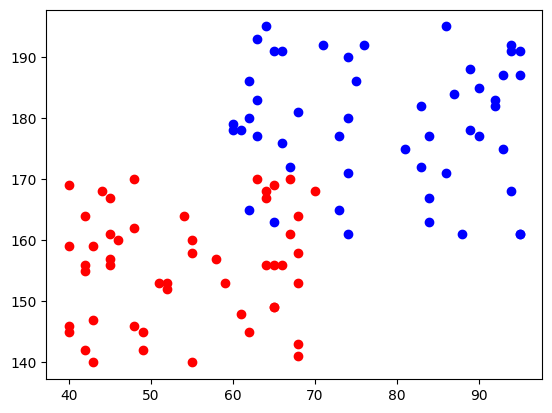

In [9]:
plt.plot([female[0] for female in data[::2]],
         [female[1] for female in data[::2]], 'o', color='r')
plt.plot([male[0] for male in data[1::2]],
        [male[1] for male in data[1::2]], 'o', color='b')
plt.show()

# 2. 군집화 로직

In [10]:
# 초기 랜덤 지점 2개
random_poinsts = [
    [random.randint(40,90), random.randint(140,195)],
    [random.randint(40,90), random.randint(140,195)]
]
random_poinsts

[[71, 157], [49, 152]]

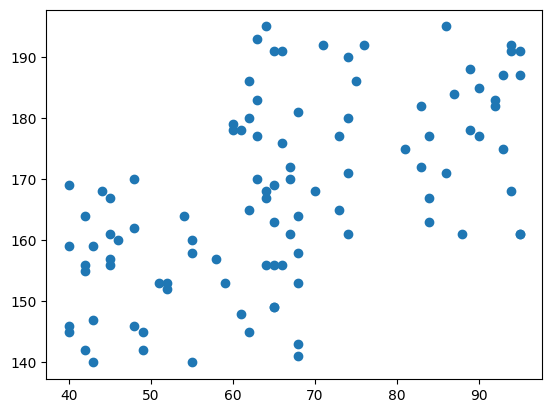

In [12]:
plt.plot([d[0] for d in data],
         [d[1] for d in data], 'o')

In [13]:
# 두점 거리를 return하는 함수 점은 [50,160]
def dist(a, b):
    return np.sqrt( (a[0]-b[0])**2 + (a[1]-b[1])**2 )
print(dist([3,4], [0,0]))
print(dist([5,7], [-1,-1]))

5.0
10.0


In [14]:
# random_points[0]에 가까운 그룹(group0)과 random_points[1]에 가까운 그룹(group1)을 분류
group0 = []
group1 = []
for d in data:
    if dist(random_poinsts[0], d) < dist(random_poinsts[1], d):
        group0.append(d)
    else:
        group1.append(d)
len(group0), len(group1)

(67, 33)

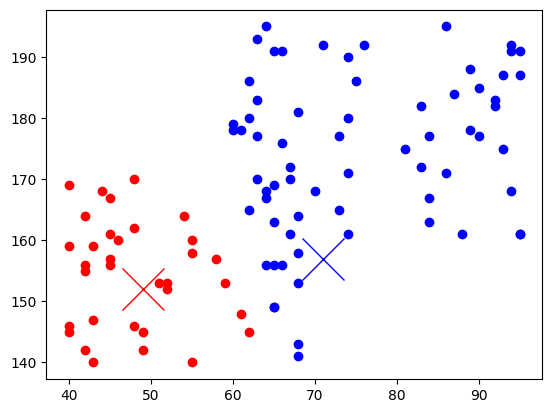

In [15]:
# group0과 group1, random_points[0]과 random_points[1]
plt.plot([d[0] for d in group0], [d[1] for d in group0], 'o', color='b')
plt.plot([d[0] for d in group1], [d[1] for d in group1], 'o', color='r')
plt.plot(random_poinsts[0][0], random_poinsts[0][1], 'x', markersize=30, color='b')
plt.plot(random_poinsts[1][0], random_poinsts[1][1], 'x', markersize=30, color='r')
plt.show()